![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [ ]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
# !pip install -r requirements.txt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn import metrics
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [2]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [3]:
df.shape

(541462, 3)

<Axes: >

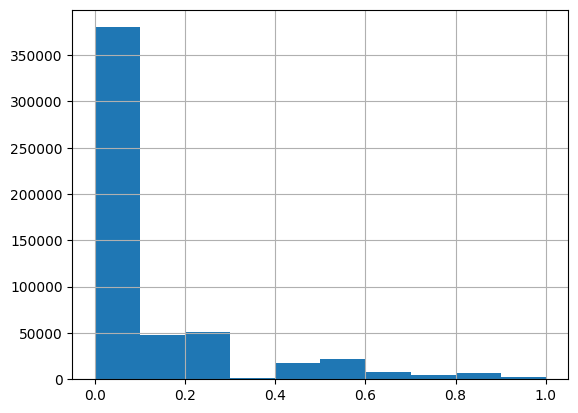

In [4]:
# Impresión histograma de variable de interés (y)
df.target.hist()

In [5]:
# Separación de variable de interés (y)
y = df.target
y.describe()

,target
count,541462.000000
mean,0.102991
std,0.196979
min,0.000000
25%,0.000000
50%,0.000000
75%,0.166667
max,1.000000


In [6]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [7]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 1


## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 2


## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

## Punto 3 - TfidfVectorizer

TfidfVectorizer es una técnica de representación de texto la cual que transforma los documentos escritos(lenguaje natural) en vectores numéricos. la razón de esta ténica es debido a que los modelos computaciones no pueden trabajar directamente con palabras sino con numeros.

TfidfVectorizer combina dos conceptos principales:
1. Frecuencia de un término(palabra, letra, frase) dentro de un documento
2. Que tan importante es este término dentro de todo el conjunto del documento

TFIDF proviene de un acronimo de: Term Frequency(Frencuencia del termino), Inverse Document Frecuency (Frencuencia Inversa Documento)es decir que tan comun o rara es el termino ya que:
si el termino aparece muchas veces el IDF es bajo.
si el termino aparece pocas veces el IDF es alto.


Como se comentó anteriormiente, TF,  mide cuántas veces aparece una palabra dentro de un documento. Si un termino aparece muchas veces en un texto es  probablemente que sea importante para describir el contenido de ese texto.  Ejemplo: si en un documento aparece muchas veces la palabra modelos, esa palabra puede ser relevante o representar la idea central del documento, sin embargo el saber la frecuencia de la palabra no es disciente por si sola, Algunas palabras aparecen muchas veces en casi todos los documentos, pero no aportan mucha información para diferenciarlos. Por ejemplo, palabras como "LA",  "LOS", "EL", "ENTONCES" pueden aparecer en muchos documentos y con una alta frecuencia, pero no siempre ayudan a identificar la idea principal del texto.

Por eso se usa IDF. Esta parte de la tecnica mide qué tan común o rara es una palabra dentro de todo el conjunto de documentos. Si una palabra aparece en muchos documentos, su peso disminuye porque se considera menos informativa. En cambio, si una palabra aparece en pocos documentos, su peso aumenta porque puede ayudar más a diferenciar un texto de otro.

la estructura de la tecnica sigue los siguientes paso

1. Identificar que terminos se van analizar.
2. Dividir el texto en tokens de acuerdo a los termino, los cuales normalmente son palabras.
3. Se construye un diccionario con los terminos encontradas en el texto.
4. Calcular la frecuencia de cada termino en cada texto (TF).
5. La frencuencia se ajusta usando el valor IDF, con el fin de reducir el peso de palabras muy comunes y aumentar el peso de palabras más distintivas.


Despues de seguir los pasos se construye una matriz numérica en donde cada fila representa un documento y cada columna representa un termino del vocabulario.

Los valores son pesos  calculados usando TF e IDF. si un valor es alto indica que una palabra es importante dentro de un documento y por consiguiente no es demasiado común en el resto del texto.


A diferencia de CountVectorizer, TFIDFVectorizer suele ser más útil porque no solamente tiene en cuenta cuántas veces aparece una palabra (TF), sino también qué tan relevante es esa palabra dentro del conjunto completo de textos (IDF). por lo tanto CountVectorizer puede darle importancia a palabras frecuentes pero poco informativas como conectores los cuales son muy frecuentes en textos.

Otra ventaja de TFIDFVectorizer es que mantiene una representación simple y eficiente. No requiere modelos complejos, por lo que es una técnica muy usada como punto de partida en problemas de procesamiento de lenguaje natural.

Sin embargo, una de las principales desventajas de TFIDFVectorizer es que sigue basándose en frecuencias de palabras por lo que entiende el significado de las palabras sino reconocer la frecuencia e importancia.

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [9]:
# Celda 4
tfidf_vect = TfidfVectorizer()
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

modelo_tfidf = Ridge(random_state=42)
modelo_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = modelo_tfidf.predict(X_test_tfidf)

mse_tfidf = mean_squared_error(y_test, y_pred_tfidf)
print('MSE con TfidfVectorizer:', mse_tfidf)

MSE con TfidfVectorizer: 0.01805127606588911


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

In [ ]:
# Celda 5 Código para graficos y tablas comparativas


In [ ]:
### Punto 5.1 - Comparación y análisis de resultados
